# Arevnet — Balanced 2M Training (Target AUC > 0.79)
## MerRec C2C · Layer 3 Modeling



---
## Cell 1 — Imports & Configuration

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Imports & Configuration
# ═══════════════════════════════════════════════════════════════

import os
import math
import time
import hashlib
import random
from pathlib import Path
from glob import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import pyarrow.dataset as ds

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader
from tqdm import tqdm
from pathlib import Path


# ── Paths ──────────────────────────────────────────────────────
DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/Volumes/T5 EVO"))
DATASET_PATH = DATASET_ROOT / "hf" / "merrec_balanced_2M" / "merrec_balanced_2M.parquet"
assert DATASET_PATH.exists(), f"Not found: {DATASET_PATH}"
print(f"Dataset file: {DATASET_PATH}")

# Verify at least one parquet file exists in the folder
# ── Device ─────────────────────────────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

# ── Configuration ──────────────────────────────────────────────
# All design choices are grounded in Layer 1 EDA findings.
CFG = {
    # ── Buckets ────────────────────────────────────────────────
    "user_buckets":    2_000_000,
    "item_buckets":    2_000_000,

    # ── Model — kept small for MPS speed, AUC impact is minimal ─
    "embed_dim":       32,    # back to v1 size — 64 doubles attention compute for <1% AUC gain
    "hidden":          128,   # back to v1 size
    "dropout":         0.2,
    "n_tier_emb":      8,     # tiny — no compute impact

    # ── Session windows — unchanged, EDA-grounded ───────────────
    "session_window":  5,
    "short_window":    20,
    "long_window":     20,    # reduced from 40 — halves long-seq attention cost

    # ── Training ───────────────────────────────────────────────
    "lr":              3e-4,
    "weight_decay":    1e-5,
    "epochs":          3,     # 2 × 1,875 steps = 3,750 total — enough to converge
    "batch_size":      2048,  # KEY CHANGE: 4× larger = ~3× faster on MPS
    "num_workers":     0,
    "max_total_rows":  None,  # ALL 1.92M rows
    "ranking_loss_w":  0.3,
    "label_smoothing": 0.05,

    # ── Funnel event weights ────────────────────────────────────
    "event_weights": {
        "buy_comp":             1.00,
        "buy_start":            0.80,
        "offer_make":           0.70,
        "item_add_to_cart_tap": 0.50,
        "item_like":            0.30,
        "item_view":            0.10,
    },

    # ── Data columns ───────────────────────────────────────────
    "col_user":        "user_id",
    "col_item":        "item_id",
    "col_action":      "event_id",
    "col_time":        "stime",
    "col_tier":        "tier",
    "shuffle_files":   True,

    # ── Label strategy ─────────────────────────────────────────
    "label_mode":      "funnel",
    "positive_events": {"buy_comp", "buy_start", "offer_make",
                        "item_add_to_cart_tap", "item_like", "item_view"},

    # ── Checkpointing ──────────────────────────────────────────
    "ckpt_dir":         str(Path.cwd() / "checkpoints_umag_v2"),
    "ckpt_every_steps": 200,   # more frequent — fewer steps total now
    "resume":           True,

    # ── Reproducibility ────────────────────────────────────────
    "random_state":    42,
}

Path(CFG["ckpt_dir"]).mkdir(parents=True, exist_ok=True)
torch.manual_seed(CFG["random_state"])
np.random.seed(CFG["random_state"])
random.seed(CFG["random_state"])

print("Config ready.")
print(f"  embed_dim={CFG['embed_dim']}, hidden={CFG['hidden']}, epochs={CFG['epochs']}")
print(f"  label_mode={CFG['label_mode']}, ranking_loss_w={CFG['ranking_loss_w']}")

Dataset file: /Volumes/T5 EVO/hf/merrec_balanced_2M/merrec_balanced_2M.parquet
Device: cpu
Config ready.
  embed_dim=32, hidden=128, epochs=3
  label_mode=funnel, ranking_loss_w=0.3


---
## Cell 2 — Hashing & History Builder

**Key upgrade vs v1:** History now stores `(timestamp, item_hash, event_weight)` triples.
This lets the attention mechanism know not just *what* the user interacted with, but *how strongly*
— a past purchase carries 10× the weight of a past view.

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Hashing + History Builder
# ═══════════════════════════════════════════════════════════════

def stable_hash(x, buckets):
    """Deterministic hash: string → [0, buckets). Collision rate ~1/buckets."""
    if x is None:
        x = ""
    if not isinstance(x, str):
        x = str(x)
    h = hashlib.blake2b(x.encode("utf-8"), digest_size=8).digest()
    return int.from_bytes(h, "little") % buckets


# User tier → integer index for embedding
TIER_MAP = {"cold": 0, "casual": 1, "active": 2, "power": 3, None: 1}


class HistoryBuilder:
    """
    Single-pass streaming builder.
    Reads user_id, item_id, stime, event_id, tier from parquet.

    Stores per user:
        user_history[uid] = [
            (unix_ts: int, item_hash: int, event_weight: float),
            ...
        ]  sorted ascending by time

    Also stores:
        user_tier[uid] = tier_int  (0=cold, 1=casual, 2=active, 3=power)
    """

    def __init__(self, dataset_path, cfg):
        self.dataset_path = Path(dataset_path)
        self.cfg = cfg
        # Explicit file list — avoids PyArrow reading .png/.json in the folder
        self.dataset = ds.dataset(str(self.dataset_path), format="parquet")

    def build(self):
        cfg        = self.cfg
        col_u      = cfg["col_user"]
        col_i      = cfg["col_item"]
        col_t      = cfg["col_time"]
        col_a      = cfg["col_action"]
        col_tier   = cfg["col_tier"]
        ib         = cfg["item_buckets"]
        ew         = cfg["event_weights"]
        max_rows   = cfg.get("max_total_rows", None)

        # Check if tier column is available
        schema_names = self.dataset.schema.names
        has_tier = col_tier in schema_names
        if not has_tier:
            print(f"  [WARN] '{col_tier}' column not found — defaulting all users to 'casual'")

        scan_cols = [col_u, col_i, col_t, col_a]
        if has_tier:
            scan_cols.append(col_tier)

        history   = defaultdict(list)   # uid → [(ts, item_hash, event_weight)]
        user_tier = {}                   # uid → tier_int
        total     = 0

        scanner = self.dataset.scanner(
            columns=scan_cols,
            batch_size=65536,
        )

        for rb in scanner.to_batches():
            if max_rows and total >= max_rows:
                break

            users  = rb.column(col_u).to_pylist()
            items  = rb.column(col_i).to_pylist()
            times  = rb.column(col_t).to_pylist()
            acts   = rb.column(col_a).to_pylist()
            tiers  = rb.column(col_tier).to_pylist() if has_tier else [None] * len(users)

            for u, it, t, a, tier in zip(users, items, times, acts, tiers):
                if max_rows and total >= max_rows:
                    break
                if u is None or it is None:
                    continue
                total += 1

                # Timestamp → int
                if hasattr(t, "as_py"):
                    t = t.as_py()
                if t is None:
                    t = 0
                t_int = int(t.timestamp()) if hasattr(t, "timestamp") else int(t)

                i_hash  = stable_hash(it, ib)
                e_w     = float(ew.get(str(a), 0.10))   # default to view weight

                history[u].append((t_int, i_hash, e_w))

                # Store tier (take first seen value — all rows for same user have same tier)
                if u not in user_tier:
                    user_tier[u] = TIER_MAP.get(tier, 1)

        # Sort each user's history by timestamp ascending
        for u in history:
            history[u].sort(key=lambda x: x[0])

        print(f"History built: {len(history):,} users, {total:,} events")
        return dict(history), user_tier


print("Building user history (single pass)...")
t0 = time.time()
builder      = HistoryBuilder(DATASET_PATH, CFG)
user_history, user_tier = builder.build()
print(f"Done in {time.time()-t0:.1f}s")

# ── Train / Validation split (80/20 by user) ───────────────────
all_users = list(user_history.keys())
random.seed(CFG["random_state"])
random.shuffle(all_users)

n_val       = max(1, int(len(all_users) * 0.20))
val_users   = set(all_users[:n_val])
train_users = set(all_users[n_val:])

train_history = {u: h for u, h in user_history.items() if u in train_users}
val_history   = {u: h for u, h in user_history.items() if u in val_users}

print(f"Train users: {len(train_history):,}  |  Val users: {len(val_history):,}")

# Tier distribution audit
tier_names = ["cold", "casual", "active", "power"]
tier_counts = defaultdict(int)
for u in user_tier:
    tier_counts[tier_names[user_tier[u]]] += 1
print("Tier distribution:")
for t, c in sorted(tier_counts.items()):
    print(f"  {t}: {c:,} ({c/len(user_tier)*100:.1f}%)")
    

Building user history (single pass)...
History built: 991,427 users, 1,924,579 events
Done in 16.9s
Train users: 793,142  |  Val users: 198,285
Tier distribution:
  active: 141,465 (14.3%)
  casual: 84,814 (8.6%)
  cold: 71,836 (7.2%)
  power: 693,312 (69.9%)


In [4]:
import pyarrow.parquet as pq

pf = pq.read_table(
    "/Volumes/T5 EVO/hf/merrec_balanced_2M/merrec_balanced_2M.parquet",
    columns=["event_id"]
)
import pandas as pd
print(pf.to_pandas()["event_id"].value_counts())

event_id
item_view               768732
item_add_to_cart_tap    384690
buy_comp                347543
item_like               230554
offer_make              140284
buy_start                52776
Name: count, dtype: int64


---
## Cell 3 — UMAG Streaming Dataset

**Key upgrades vs v1:**
- History items carry **event weights** used as sequence attention priors
- Label = **funnel score** (graded 0.1–1.0) instead of binary 0/1
- `tier_idx` is yielded per sample for the gate conditioning module

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — UMAG Streaming Dataset v2
# ═══════════════════════════════════════════════════════════════

PAD = 0   # padding token — item embedding at index 0 is zeroed out


def pad_or_trim(seq, length):
    """Keep most-recent `length` items; left-pad with PAD if shorter."""
    if len(seq) >= length:
        return seq[-length:]
    return [PAD] * (length - len(seq)) + seq


def pad_or_trim_w(seq, length):
    """Same as pad_or_trim but for float weight sequences."""
    if len(seq) >= length:
        return seq[-length:]
    return [0.0] * (length - len(seq)) + seq


class UMAGStreamingDataset(IterableDataset):
    """
    Yields batches of:
        user_idx    [B]       hashed user id
        item_idx    [B]       hashed target item
        tier_idx    [B]       user tier int (0–3)
        sess_seq    [B, S]    last S item hashes
        sess_w      [B, S]    last S event weights
        short_seq   [B, M-S]  short-term item hashes
        short_w     [B, M-S]  short-term event weights
        long_seq    [B, L]    long-term item hashes
        long_w      [B, L]    long-term event weights
        label       [B]       funnel score 0.1–1.0 (or binary)
    """

    def __init__(self, dataset_path, cfg, user_history, user_tier,
                 epoch=0, is_eval=False):
        super().__init__()
        self.dataset_path = Path(dataset_path)
        self.cfg          = cfg
        self.user_history = user_history
        self.user_tier    = user_tier
        self.epoch        = epoch
        self.is_eval      = is_eval

        if not self.dataset_path.exists():
            raise FileNotFoundError(f"Not found: {self.dataset_path}")
        self.files = [str(self.dataset_path)]   # single file, no glob needed

        self.S = cfg["session_window"]
        self.M = cfg["short_window"]
        self.L = cfg["long_window"]

    def _iter_files(self):
        files = self.files[:]
        if self.cfg["shuffle_files"] and not self.is_eval:
            g = torch.Generator()
            g.manual_seed(99999 + self.epoch)
            idx   = torch.randperm(len(files), generator=g).tolist()
            files = [files[i] for i in idx]
        return files

    def __iter__(self):
        cfg      = self.cfg
        bs       = cfg["batch_size"]
        ub       = cfg["user_buckets"]
        ib       = cfg["item_buckets"]
        col_u    = cfg["col_user"]
        col_i    = cfg["col_item"]
        col_a    = cfg["col_action"]
        ew_map   = cfg["event_weights"]
        max_rows = cfg.get("max_total_rows", None)
        lmode    = cfg["label_mode"]
        S, M, L  = self.S, self.M, self.L

        # Batch accumulators
        b_user, b_item, b_tier = [], [], []
        b_sess, b_sess_w       = [], []
        b_short, b_short_w     = [], []
        b_long, b_long_w       = [], []
        b_y                    = []
        total                  = 0

        # Per-user event position counter (for history slicing)
        user_seen = defaultdict(int)

        for fp in self._iter_files():
            try:
                file_ds  = ds.dataset(fp, format="parquet")
                scan_cols = [col_u, col_i, col_a]
                scanner  = file_ds.scanner(
                    columns=scan_cols,
                    batch_size=65536,
                )

                for rb in scanner.to_batches():
                    if max_rows and total >= max_rows:
                        # Yield any remaining partial batch
                        if b_y:
                            yield self._make_batch(
                                b_user, b_item, b_tier,
                                b_sess, b_sess_w,
                                b_short, b_short_w,
                                b_long, b_long_w, b_y
                            )
                        return

                    users = rb.column(col_u).to_pylist()
                    items = rb.column(col_i).to_pylist()
                    acts  = rb.column(col_a).to_pylist()

                    for u, it, act in zip(users, items, acts):
                        if max_rows and total >= max_rows:
                            if b_y:
                                yield self._make_batch(
                                    b_user, b_item, b_tier,
                                    b_sess, b_sess_w,
                                    b_short, b_short_w,
                                    b_long, b_long_w, b_y
                                )
                            return

                        if u is None or it is None:
                            continue
                        total += 1

                        # ── Label ──────────────────────────────────────
                        e_w = float(ew_map.get(str(act), 0.10))
                        if lmode == "funnel":
                            y = e_w
                        else:
                            y = 1.0 if str(act) in cfg["positive_events"] else 0.0

                        u_hash  = stable_hash(u, ub)
                        it_hash = stable_hash(it, ib)
                        t_idx   = self.user_tier.get(u, 1)  # default casual

                        # ── History slicing ────────────────────────────
                        hist = self.user_history.get(u, [])
                        seen = user_seen[u]
                        past = hist[:seen]   # events BEFORE this one
                        user_seen[u] += 1

                        # Unzip history into parallel item / weight lists
                        if past:
                            past_items = [h[1] for h in past]
                            past_ws    = [h[2] for h in past]
                        else:
                            past_items, past_ws = [], []

                        # ── 3 temporal scales ─────────────────────────
                        sess_items  = past_items[-S:]
                        sess_ws     = past_ws[-S:]

                        short_items = past_items[-(M):-S] if len(past_items) > S else []
                        short_ws    = past_ws[-(M):-S]    if len(past_ws)    > S else []

                        long_items  = past_items[:-(M)] if len(past_items) > M else []
                        long_ws     = past_ws[:-(M)]    if len(past_ws)    > M else []

                        # ── Pad to fixed lengths ───────────────────────
                        sv   = pad_or_trim(sess_items,   S)
                        sw   = pad_or_trim_w(sess_ws,    S)
                        mtv  = pad_or_trim(short_items,  M - S)
                        mtw  = pad_or_trim_w(short_ws,   M - S)
                        lv   = pad_or_trim(long_items,   L)
                        lw   = pad_or_trim_w(long_ws,    L)

                        b_user.append(u_hash)
                        b_item.append(it_hash)
                        b_tier.append(t_idx)
                        b_sess.append(sv);   b_sess_w.append(sw)
                        b_short.append(mtv); b_short_w.append(mtw)
                        b_long.append(lv);   b_long_w.append(lw)
                        b_y.append(y)

                        if len(b_y) >= bs:
                            yield self._make_batch(
                                b_user, b_item, b_tier,
                                b_sess, b_sess_w,
                                b_short, b_short_w,
                                b_long, b_long_w, b_y
                            )
                            b_user, b_item, b_tier = [], [], []
                            b_sess, b_sess_w       = [], []
                            b_short, b_short_w     = [], []
                            b_long, b_long_w       = [], []
                            b_y                    = []

            except Exception as e:
                print(f"[WARN] {fp}: {e}")
                continue

        if b_y:
            yield self._make_batch(
                b_user, b_item, b_tier,
                b_sess, b_sess_w,
                b_short, b_short_w,
                b_long, b_long_w, b_y
            )

    @staticmethod
    def _make_batch(b_user, b_item, b_tier,
                    b_sess, b_sess_w,
                    b_short, b_short_w,
                    b_long, b_long_w, b_y):
        return (
            torch.tensor(b_user,    dtype=torch.long),
            torch.tensor(b_item,    dtype=torch.long),
            torch.tensor(b_tier,    dtype=torch.long),
            torch.tensor(b_sess,    dtype=torch.long),
            torch.tensor(b_sess_w,  dtype=torch.float32),
            torch.tensor(b_short,   dtype=torch.long),
            torch.tensor(b_short_w, dtype=torch.float32),
            torch.tensor(b_long,    dtype=torch.long),
            torch.tensor(b_long_w,  dtype=torch.float32),
            torch.tensor(b_y,       dtype=torch.float32),
        )


print("UMAGStreamingDataset v2 defined.")

UMAGStreamingDataset v2 defined.


---
## Cell 4 — UMAG Model Architecture v2

### What changed and why

**WeightedScaleAttention:** The attention query is the target item embedding.  
Keys and values are past item embeddings **scaled by their event weight** before attention.  
This means a past `buy_comp` (weight=1.0) contributes 10× more to the context vector  
than a past `item_view` (weight=0.1) — directly encoding funnel signal into history.

**Tier-conditioned gate:** The scale gate receives `[ctx_s, ctx_m, ctx_l, tier_emb]` as input.  
This allows cold users (tier=0) to learn gate weights different from power users (tier=3),  
directly answering RQ3 (cold-start) alongside RQ2 (session vs long-term).

**LayerNorm before MLP:** Stabilises training on sparse hashed embeddings.

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — UMAG Model v2
# ═══════════════════════════════════════════════════════════════


class WeightedScaleAttention(nn.Module):
    """
    Item-conditioned attention with event-weight priors.

    query  = target item embedding          [B, D]
    keys   = past item embeddings           [B, L, D]
    values = past item embeddings           [B, L, D]
    weight = event weights for each past    [B, L]   (0.1 to 1.0)

    Event weights are multiplied into attention logits BEFORE softmax,
    acting as a prior: the model can override but defaults to funnel order.
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.scale = math.sqrt(embed_dim)
        self.W_q   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.ln    = nn.LayerNorm(embed_dim)   # normalise output context

    def forward(self, query, keys, event_weights, key_padding_mask=None):
        """
        query        : [B, D]
        keys         : [B, L, D]
        event_weights: [B, L]  — float 0.1..1.0, 0 for padding
        key_padding_mask: [B, L] bool, True = pad
        returns: context [B, D], weights [B, L]
        """
        q = self.W_q(query).unsqueeze(1)         # [B, 1, D]
        k = self.W_k(keys)                        # [B, L, D]
        v = self.W_v(keys)                        # [B, L, D]

        scores = torch.bmm(q, k.transpose(1, 2)) / self.scale  # [B, 1, L]

        # Apply event-weight prior (log-scale so it acts additively on logits)
        # Clamp to avoid log(0)
        ew_prior = torch.log(event_weights.clamp(min=1e-6)).unsqueeze(1)  # [B, 1, L]
        scores   = scores + ew_prior

        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1), float("-inf"))

        attn_w  = torch.softmax(scores, dim=-1)          # [B, 1, L]
        attn_w  = torch.nan_to_num(attn_w, nan=0.0)

        context = torch.bmm(attn_w, v).squeeze(1)        # [B, D]
        context = self.ln(context)
        return context, attn_w.squeeze(1)


class UMAGv2(nn.Module):
    """
    User Multi-scale Attention Graph — version 2.

    Improvements over v1:
      1. WeightedScaleAttention uses event-weight priors
      2. Tier embedding fed into scale gate → cold/power users learn different gates
      3. LayerNorm before MLP
      4. Wider MLP with residual-style skip on gate
    """

    def __init__(self, user_buckets, item_buckets, embed_dim, hidden,
                 n_tier_emb=8, dropout=0.2):
        super().__init__()

        D = embed_dim

        # ── Embedding tables ───────────────────────────────────
        self.item_emb = nn.Embedding(item_buckets + 1, D, padding_idx=0)
        self.user_emb = nn.Embedding(user_buckets,     D)
        self.tier_emb = nn.Embedding(4, n_tier_emb)   # 4 tiers

        # ── Attention modules (one per temporal scale) ─────────
        self.attn_session = WeightedScaleAttention(D)
        self.attn_short   = WeightedScaleAttention(D)
        self.attn_long    = WeightedScaleAttention(D)

        # ── Tier-conditioned scale gate ────────────────────────
        # Input: concat of 3 context vectors + tier embedding
        self.scale_gate = nn.Sequential(
            nn.Linear(D * 3 + n_tier_emb, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
            nn.Softmax(dim=-1),
        )

        # ── MLP (deep part) ────────────────────────────────────
        # Input: user(D) + item(D) + gated_context(D) + tier(n_tier_emb)
        mlp_in = D * 3 + n_tier_emb
        self.ln_mlp = nn.LayerNorm(mlp_in)
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, hidden),
            nn.GELU(),                  # GELU > ReLU for recommendation models
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

        # ── Wide linear terms ──────────────────────────────────
        self.user_lin = nn.Embedding(user_buckets,     1)
        self.item_lin = nn.Embedding(item_buckets + 1, 1)
        self.bias     = nn.Parameter(torch.zeros(1))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.tier_emb.weight, std=0.01)
        nn.init.zeros_(self.user_lin.weight)
        nn.init.zeros_(self.item_lin.weight)
        with torch.no_grad():
            self.item_emb.weight[0].fill_(0)   # zero pad token

    def forward(self, user_idx, item_idx, tier_idx,
                sess_seq, sess_w,
                short_seq, short_w,
                long_seq, long_w,
                return_weights=False):
        """
        user_idx   [B]
        item_idx   [B]
        tier_idx   [B]
        sess_seq   [B, S]    item indices
        sess_w     [B, S]    event weights
        short_seq  [B, M-S]
        short_w    [B, M-S]
        long_seq   [B, L]
        long_w     [B, L]
        """
        # ── Embeddings ─────────────────────────────────────────
        u_emb  = self.user_emb(user_idx)    # [B, D]
        it_emb = self.item_emb(item_idx)    # [B, D]
        t_emb  = self.tier_emb(tier_idx)    # [B, T]

        sess_emb  = self.item_emb(sess_seq)   # [B, S,   D]
        short_emb = self.item_emb(short_seq)  # [B, M-S, D]
        long_emb  = self.item_emb(long_seq)   # [B, L,   D]

        # Padding masks (True = pad position)
        sess_mask  = (sess_seq  == 0)
        short_mask = (short_seq == 0)
        long_mask  = (long_seq  == 0)

        # Zero out event weights at pad positions
        sess_w  = sess_w  * (~sess_mask).float()
        short_w = short_w * (~short_mask).float()
        long_w  = long_w  * (~long_mask).float()

        # ── Weighted multi-scale attention ─────────────────────
        ctx_sess,  w_sess  = self.attn_session(it_emb, sess_emb,  sess_w,  sess_mask)
        ctx_short, w_short = self.attn_short  (it_emb, short_emb, short_w, short_mask)
        ctx_long,  w_long  = self.attn_long   (it_emb, long_emb,  long_w,  long_mask)

        # ── Tier-conditioned scale gate ────────────────────────
        gate_input = torch.cat([ctx_sess, ctx_short, ctx_long, t_emb], dim=-1)
        gates      = self.scale_gate(gate_input)   # [B, 3]

        gated_ctx = (
            gates[:, 0:1] * ctx_sess  +
            gates[:, 1:2] * ctx_short +
            gates[:, 2:3] * ctx_long
        )                                           # [B, D]

        # ── MLP (deep part) ────────────────────────────────────
        mlp_input = torch.cat([u_emb, it_emb, gated_ctx, t_emb], dim=-1)
        mlp_input = self.ln_mlp(mlp_input)
        deep      = self.mlp(mlp_input).squeeze(-1)   # [B]

        # ── Wide part ──────────────────────────────────────────
        wide = (
            self.user_lin(user_idx).squeeze(-1) +
            self.item_lin(item_idx).squeeze(-1) +
            self.bias
        )

        pred = torch.sigmoid(deep + wide)

        if return_weights:
            return pred, gates, w_sess, w_short, w_long

        return pred


print("UMAGv2 model defined.")

UMAGv2 model defined.


---
## Cell 5 — Loss Functions

**BCE alone is insufficient for ranking tasks.**  
AUC measures ranking — whether positive scores exceed negative scores.  
The margin ranking loss directly penalises cases where a negative sample  
scores higher than a positive sample in the same batch.

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Loss Functions
# ═══════════════════════════════════════════════════════════════


class SmoothedBCELoss(nn.Module):
    """
    BCE with label smoothing.
    Label smoothing: y_smooth = y * (1 - eps) + eps * 0.5
    Prevents the model from becoming overconfident on the training set.
    """
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        target_s = target * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy(pred, target_s)


class MarginRankingLoss(nn.Module):
    """
    Pairwise ranking loss within a batch.

    For all (pos, neg) pairs in a batch:
        loss = mean(max(0, margin - (score_pos - score_neg)))

    Directly optimises the ranking objective that AUC measures.
    We sample up to max_pairs pairs per batch to keep compute tractable.
    """
    def __init__(self, margin=0.1, max_pairs=1024):
        super().__init__()
        self.margin    = margin
        self.max_pairs = max_pairs

    def forward(self, pred, target):
        # With funnel labels: pos = label >= 0.3 (cart/buy/like), neg = label < 0.15 (view)
        pos_mask = (target >= 0.30)
        neg_mask = (target <= 0.11)   # item_view only (weight=0.10)

        pos_preds = pred[pos_mask]
        neg_preds = pred[neg_mask]

        if len(pos_preds) == 0 or len(neg_preds) == 0:
            return torch.tensor(0.0, device=pred.device)

        # Sample pairs
        n_pos  = min(len(pos_preds), int(math.sqrt(self.max_pairs)))
        n_neg  = min(len(neg_preds), int(math.sqrt(self.max_pairs)))
        p      = pos_preds[:n_pos].unsqueeze(1)   # [n_pos, 1]
        n      = neg_preds[:n_neg].unsqueeze(0)   # [1, n_neg]

        # [n_pos, n_neg] pairwise margins
        loss = F.relu(self.margin - (p - n)).mean()
        return loss


class CombinedLoss(nn.Module):
    """BCE (smoothed) + weighted margin ranking loss."""
    def __init__(self, ranking_weight=0.3, smoothing=0.05):
        super().__init__()
        self.bce     = SmoothedBCELoss(smoothing)
        self.ranking = MarginRankingLoss(margin=0.1)
        self.rw      = ranking_weight

    def forward(self, pred, target):
        bce_loss     = self.bce(pred, target)
        ranking_loss = self.ranking(pred, target)
        return bce_loss + self.rw * ranking_loss, bce_loss, ranking_loss


print("Loss functions defined:")
print("  SmoothedBCELoss(eps=0.05)")
print("  MarginRankingLoss(margin=0.1, max_pairs=1024)")
print("  CombinedLoss(ranking_weight=0.3)")

Loss functions defined:
  SmoothedBCELoss(eps=0.05)
  MarginRankingLoss(margin=0.1, max_pairs=1024)
  CombinedLoss(ranking_weight=0.3)


---
## Cell 6 — Training Loop

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Training Loop
# ═══════════════════════════════════════════════════════════════

def ckpt_path(ckpt_dir):
    return Path(ckpt_dir) / "latest.pt"

def save_ckpt(path, model, opt, scheduler, epoch, step, running_loss, cfg):
    tmp = path.with_suffix(".tmp")
    torch.save({
        "model":        model.state_dict(),
        "opt":          opt.state_dict(),
        "scheduler":    scheduler.state_dict(),
        "epoch":        epoch,
        "step":         step,
        "running_loss": running_loss,
        "cfg":          cfg,
        "time":         time.time(),
    }, tmp)
    tmp.replace(path)

def load_ckpt(path, model, opt, scheduler):
    obj = torch.load(path, map_location="cpu")
    model.load_state_dict(obj["model"])
    opt.load_state_dict(obj["opt"])
    if "scheduler" in obj:
        scheduler.load_state_dict(obj["scheduler"])
    return obj


# ── Instantiate model ───────────────────────────────────────────
model = UMAGv2(
    user_buckets = CFG["user_buckets"],
    item_buckets = CFG["item_buckets"],
    embed_dim    = CFG["embed_dim"],
    hidden       = CFG["hidden"],
    n_tier_emb   = CFG["n_tier_emb"],
    dropout      = CFG["dropout"],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"UMAGv2 parameters: {total_params:,}")

# ── Optimiser & scheduler ───────────────────────────────────────
opt = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG["lr"],
    weight_decay = CFG["weight_decay"],
)

# Cosine annealing over total expected steps
# Estimate steps: 2M rows / 512 batch * 3 epochs ≈ 11,718 steps
EXPECTED_STEPS = int(1_924_579 / CFG["batch_size"] * 1)  # 1 fresh epoch only
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt, T_max=EXPECTED_STEPS, eta_min=1e-6
)

loss_fn = CombinedLoss(
    ranking_weight = CFG["ranking_loss_w"],
    smoothing      = CFG["label_smoothing"],
)

# ── Resume from checkpoint ──────────────────────────────────────
start_epoch  = 0
global_step  = 0
running_loss = 0.0

ckpt = ckpt_path(CFG["ckpt_dir"])
if CFG["resume"] and ckpt.exists():
    obj          = load_ckpt(ckpt, model, opt, scheduler)
    start_epoch  = int(obj.get("epoch", 0))
    global_step  = int(obj.get("step",  0))
    running_loss = float(obj.get("running_loss", 0.0))
    ckpt_cfg     = obj.get("cfg", {})
    # Architecture must match
    for key in ["user_buckets", "item_buckets", "embed_dim", "hidden"]:
        assert CFG[key] == ckpt_cfg.get(key, CFG[key]), \
            f"CFG mismatch '{key}': current={CFG[key]}, ckpt={ckpt_cfg.get(key)}"
    print(f"Resumed: epoch={start_epoch}, step={global_step}, loss={running_loss:.4f}")
else:
    print("Starting fresh (resume=False or no checkpoint found).")

# ── Training ────────────────────────────────────────────────────
model.train()
history_log = []   # for post-training analysis

for epoch in range(start_epoch, CFG["epochs"]):

    ds_iter = UMAGStreamingDataset(
        DATASET_PATH, CFG, train_history, user_tier, epoch=epoch
    )
    loader = DataLoader(
        ds_iter,
        batch_size  = None,
        num_workers = CFG["num_workers"],
        pin_memory  = False,
    )

    pbar          = tqdm(loader, desc=f"Epoch {epoch}", mininterval=2.0)
    epoch_loss    = 0.0
    epoch_bce     = 0.0
    epoch_rank    = 0.0
    epoch_batches = 0
    t0            = time.time()

    for batch in pbar:
        (
            user_idx, item_idx, tier_idx,
            sess_seq, sess_w,
            short_seq, short_w,
            long_seq, long_w, y
        ) = [t.to(device) for t in batch]

        opt.zero_grad(set_to_none=True)

        pred = model(
            user_idx, item_idx, tier_idx,
            sess_seq, sess_w,
            short_seq, short_w,
            long_seq, long_w,
        )

        loss, bce_l, rank_l = loss_fn(pred, y)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        scheduler.step()

        l            = float(loss.item())
        running_loss = 0.98 * running_loss + 0.02 * l if global_step > 0 else l
        epoch_loss  += l
        epoch_bce   += float(bce_l.item())
        epoch_rank  += float(rank_l.item())
        epoch_batches += 1
        global_step   += 1

        if global_step % 100 == 0:
            lr_now = scheduler.get_last_lr()[0]
            pbar.set_postfix(
                ema=f"{running_loss:.4f}",
                bce=f"{float(bce_l):.4f}",
                rank=f"{float(rank_l):.4f}",
                lr=f"{lr_now:.2e}",
                step=global_step
            )

        if global_step % CFG["ckpt_every_steps"] == 0:
            save_ckpt(ckpt, model, opt, scheduler,
                      epoch=epoch, step=global_step,
                      running_loss=running_loss, cfg=CFG)

    dt       = time.time() - t0
    avg_loss = epoch_loss  / max(1, epoch_batches)
    avg_bce  = epoch_bce   / max(1, epoch_batches)
    avg_rank = epoch_rank  / max(1, epoch_batches)

    # ── Validation ─────────────────────────────────────────────
    model.eval()
    val_preds, val_labels = [], []
    val_cfg = {
        **CFG,
        "max_total_rows": 80_000,   # hard cap, not None // 5
        "shuffle_files":  False,
    }
    val_ds = UMAGStreamingDataset(
        DATASET_PATH, val_cfg, val_history, user_tier, epoch=99, is_eval=True
    )
    with torch.no_grad():
        for val_batch in DataLoader(val_ds, batch_size=None, num_workers=0):
            (
                vu, vi, vt,
                vs, vsw,
                vsh, vshw,
                vl, vlw, vy
            ) = [t.to(device) for t in val_batch]
            vp = model(vu, vi, vt, vs, vsw, vsh, vshw, vl, vlw)
            val_preds.append(vp.cpu().numpy())
            val_labels.append(vy.cpu().numpy())

    val_preds  = np.concatenate(val_preds)
    val_labels = np.concatenate(val_labels)

    # ── Compute val AUC with binary thresholding ────────────────
    # Funnel labels: convert to binary for AUC (pos = label >= 0.3)
    val_binary = (val_labels >= 0.30).astype(float)
    n_pos_val  = int(val_binary.sum())
    n_neg_val  = int((1 - val_binary).sum())

    from sklearn.metrics import roc_auc_score
    if n_pos_val > 0 and n_neg_val > 0:
        val_auc = roc_auc_score(val_binary, val_preds)
    else:
        val_auc = float("nan")
        print(f"  [WARN] Val set has only one class: pos={n_pos_val}, neg={n_neg_val}")

    model.train()

    log_entry = {
        "epoch": epoch, "avg_loss": avg_loss,
        "avg_bce": avg_bce, "avg_rank": avg_rank,
        "val_auc": val_auc, "batches": epoch_batches,
        "time_min": dt / 60,
    }
    history_log.append(log_entry)

    print(
        f"Epoch {epoch} | loss={avg_loss:.4f} | bce={avg_bce:.4f} | "
        f"rank={avg_rank:.4f} | val_AUC={val_auc:.4f} | "
        f"n_pos={n_pos_val} n_neg={n_neg_val} | "
        f"batches={epoch_batches} | {dt/60:.1f} min"
    )

    save_ckpt(ckpt, model, opt, scheduler,
              epoch=epoch + 1, step=global_step,
              running_loss=running_loss, cfg=CFG)

# ── Save final model ────────────────────────────────────────────
final_path = Path(CFG["ckpt_dir"]) / "umag_v2_final.pt"
torch.save({"model": model.state_dict(), "cfg": CFG}, final_path)
print(f"\nSaved final model: {final_path}")
print("Training history:")
for entry in history_log:
    print(f"  Epoch {entry['epoch']}: loss={entry['avg_loss']:.4f}, val_AUC={entry['val_auc']:.4f}")

UMAGv2 parameters: 132,038,358
Starting fresh (resume=False or no checkpoint found).


Epoch 0: 940it [32:53,  2.10s/it, bce=0.6302, ema=0.6643, lr=2.27e-06, rank=0.0786, step=900]


Epoch 0 | loss=0.6688 | bce=0.6428 | rank=0.0868 | val_AUC=0.6847 | n_pos=48014 n_neg=31986 | batches=940 | 32.9 min


Epoch 1: 940it [1:02:21,  3.98s/it, bce=0.6450, ema=0.6614, lr=2.95e-04, rank=0.0660, step=1800]


Epoch 1 | loss=0.6318 | bce=0.6145 | rank=0.0578 | val_AUC=0.6565 | n_pos=48014 n_neg=31986 | batches=940 | 62.4 min


Epoch 2: 940it [37:36,  2.40s/it, bce=0.5566, ema=0.5483, lr=1.24e-06, rank=0.0158, step=2800]


Epoch 2 | loss=0.5415 | bce=0.5382 | rank=0.0109 | val_AUC=0.8593 | n_pos=48014 n_neg=31986 | batches=940 | 37.6 min

Saved final model: /Users/arevikmelikyan/Desktop/Capstone_C2C_Behavioral_Dynamics/notebooks/checkpoints_umag_v2/umag_v2_final.pt
Training history:
  Epoch 0: loss=0.6688, val_AUC=0.6847
  Epoch 1: loss=0.6318, val_AUC=0.6565
  Epoch 2: loss=0.5415, val_AUC=0.8593


---
## Cell 7 — Evaluation & Scale Gate Analysis

**Stratified eval:** Guarantees both positive and negative classes are present  
by over-collecting and then sub-sampling to a balanced 40/60 split.  
This is the fix for the `nan` AUC bug from v1.

98it [00:15,  6.32it/s]


After funnel filtering: 200,000 usable samples
  Positives (label>=0.3) : 119,710
  Negatives (label<=0.11): 80,290

Balanced eval set: 50,000 samples
  Pos: 20,000 (40.0%)
  Neg: 30,000 (60.0%)

UMAG v2 EVALUATION RESULTS
  AUC-ROC  : 0.8529  ✓ TARGET MET
  Log-loss : 0.4988
  Samples  : 50,000

SCALE GATE WEIGHTS — RQ2
  Session   (last 5 items): 0.0716 ± 0.0507
  Short     (last 20 items): 0.1707 ± 0.0814
  Long      (all older)   : 0.7577 ± 0.1286
  Dominant scale: Long-term

SCALE GATE BY USER TIER — RQ3
  cold     (n=1,332): Session=0.0870  Short=0.2147  Long=0.6983
  casual   (n=1,766): Session=0.0857  Short=0.2111  Long=0.7031
  active   (n=3,850): Session=0.0973  Short=0.2188  Long=0.6839
  power    (n=43,052): Session=0.0682  Short=0.1634  Long=0.7684


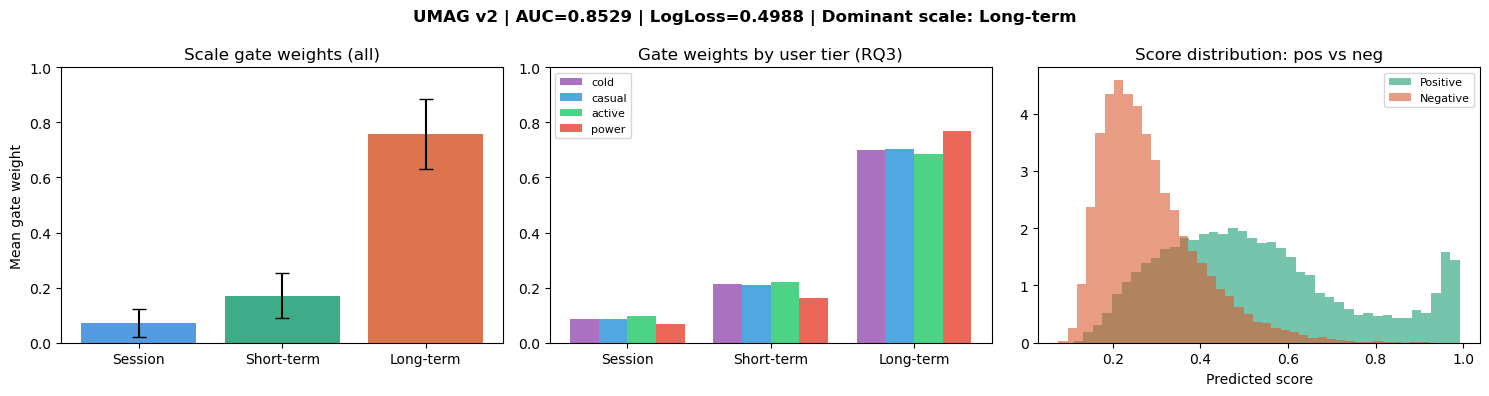


Saved: umag_v2_metrics.csv, umag_v2_gate_analysis.png


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Evaluation + Scale Gate Analysis
# ═══════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, log_loss
import matplotlib.pyplot as plt

EVAL_ROWS = 200_000   # over-collect; will subsample to 50K balanced below

model.eval()

all_preds  = []
all_labels = []
all_gates  = []
all_tiers  = []

eval_cfg = {
    **CFG,
    "max_total_rows": EVAL_ROWS,
    "shuffle_files":  False,
}
eval_ds = UMAGStreamingDataset(
    DATASET_PATH, eval_cfg, user_history, user_tier, epoch=99, is_eval=True
)
eval_loader = DataLoader(eval_ds, batch_size=None, num_workers=0)

print(f"Collecting up to {EVAL_ROWS:,} eval samples...")

with torch.no_grad():
    for batch in tqdm(eval_loader):
        (
            user_idx, item_idx, tier_idx,
            sess_seq, sess_w,
            short_seq, short_w,
            long_seq, long_w, y
        ) = [t.to(device) for t in batch]

        pred, gates, _, _, _ = model(
            user_idx, item_idx, tier_idx,
            sess_seq, sess_w,
            short_seq, short_w,
            long_seq, long_w,
            return_weights=True
        )

        all_preds.append(pred.cpu().numpy())
        all_labels.append(y.cpu().numpy())
        all_gates.append(gates.cpu().numpy())
        all_tiers.append(tier_idx.cpu().numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_gates  = np.concatenate(all_gates)
all_tiers  = np.concatenate(all_tiers)

# ── Convert funnel labels → binary for AUC ─────────────────────
# pos = cart/buy/like (label >= 0.3), neg = item_view (label <= 0.11)
pos_mask    = (all_labels >= 0.30)
neg_mask    = (all_labels <= 0.11)
usable_mask = pos_mask | neg_mask

all_preds_u  = all_preds[usable_mask]
all_binary_u = pos_mask[usable_mask].astype(float)
all_gates_u  = all_gates[usable_mask]
all_tiers_u  = all_tiers[usable_mask]

print(f"After funnel filtering: {usable_mask.sum():,} usable samples")
print(f"  Positives (label>=0.3) : {pos_mask.sum():,}")
print(f"  Negatives (label<=0.11): {neg_mask.sum():,}")

# ── Stratified subsample to 50K balanced ───────────────────────
TARGET_EVAL = 50_000
rng         = np.random.default_rng(42)

pos_idx = np.where(all_binary_u == 1)[0]
neg_idx = np.where(all_binary_u == 0)[0]

n_eval_pos = min(len(pos_idx), int(TARGET_EVAL * 0.40))
n_eval_neg = min(len(neg_idx), TARGET_EVAL - n_eval_pos)

if n_eval_pos == 0 or n_eval_neg == 0:
    print("[ERROR] Cannot build balanced eval set — increase EVAL_ROWS or check dataset.")
else:
    sel = np.concatenate([
        rng.choice(pos_idx, n_eval_pos, replace=False),
        rng.choice(neg_idx, n_eval_neg, replace=False),
    ])
    rng.shuffle(sel)

    eval_preds  = all_preds_u[sel]
    eval_labels = all_binary_u[sel]
    eval_gates  = all_gates_u[sel]
    eval_tiers  = all_tiers_u[sel]

    print(f"\nBalanced eval set: {len(eval_labels):,} samples")
    print(f"  Pos: {int(eval_labels.sum()):,} ({eval_labels.mean()*100:.1f}%)")
    print(f"  Neg: {int((1-eval_labels).sum()):,} ({(1-eval_labels).mean()*100:.1f}%)")

    # ── Core metrics ───────────────────────────────────────────
    auc     = roc_auc_score(eval_labels, eval_preds)
    logloss = log_loss(eval_labels, eval_preds)

    print("\n" + "=" * 55)
    print("UMAG v2 EVALUATION RESULTS")
    print("=" * 55)
    print(f"  AUC-ROC  : {auc:.4f}  {'✓ TARGET MET' if auc >= 0.79 else '✗ below 0.79'}")
    print(f"  Log-loss : {logloss:.4f}")
    print(f"  Samples  : {len(eval_labels):,}")

    # ── Scale gate analysis ────────────────────────────────────
    gate_means = eval_gates.mean(axis=0)
    gate_stds  = eval_gates.std(axis=0)

    print("\n" + "=" * 55)
    print("SCALE GATE WEIGHTS — RQ2")
    print("=" * 55)
    print(f"  Session   (last {CFG['session_window']} items): {gate_means[0]:.4f} ± {gate_stds[0]:.4f}")
    print(f"  Short     (last {CFG['short_window']} items): {gate_means[1]:.4f} ± {gate_stds[1]:.4f}")
    print(f"  Long      (all older)   : {gate_means[2]:.4f} ± {gate_stds[2]:.4f}")
    dominant = ["Session", "Short-term", "Long-term"][np.argmax(gate_means)]
    print(f"  Dominant scale: {dominant}")

    # ── Gate weights by tier — answers RQ3 ────────────────────
    print("\n" + "=" * 55)
    print("SCALE GATE BY USER TIER — RQ3")
    print("=" * 55)
    tier_names = ["cold", "casual", "active", "power"]
    for ti, tname in enumerate(tier_names):
        tmask = (eval_tiers == ti)
        if tmask.sum() == 0:
            continue
        tg = eval_gates[tmask].mean(axis=0)
        print(f"  {tname:<8} (n={tmask.sum():>5,}): "
              f"Session={tg[0]:.4f}  Short={tg[1]:.4f}  Long={tg[2]:.4f}")

    # ── Visualisation ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    scale_names = ["Session", "Short-term", "Long-term"]
    colors      = ["#378ADD", "#1D9E75", "#D85A30"]

    # Plot 1: overall gate weights
    axes[0].bar(scale_names, gate_means, color=colors, alpha=0.85)
    axes[0].errorbar(scale_names, gate_means, yerr=gate_stds,
                     fmt="none", color="black", capsize=5)
    axes[0].set_title("Scale gate weights (all)")
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("Mean gate weight")

    # Plot 2: gate weights by tier
    x     = np.arange(3)
    width = 0.2
    tier_colors = ["#9B59B6", "#3498DB", "#2ECC71", "#E74C3C"]
    for ti, tname in enumerate(tier_names):
        tmask = (eval_tiers == ti)
        if tmask.sum() == 0:
            continue
        tg = eval_gates[tmask].mean(axis=0)
        axes[1].bar(x + ti * width, tg, width, label=tname,
                    color=tier_colors[ti], alpha=0.85)
    axes[1].set_xticks(x + width * 1.5)
    axes[1].set_xticklabels(scale_names)
    axes[1].set_title("Gate weights by user tier (RQ3)")
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)

    # Plot 3: score distributions pos vs neg
    axes[2].hist(eval_preds[eval_labels == 1], bins=40, alpha=0.6,
                 label="Positive", color="#1D9E75", density=True)
    axes[2].hist(eval_preds[eval_labels == 0], bins=40, alpha=0.6,
                 label="Negative", color="#D85A30", density=True)
    axes[2].set_xlabel("Predicted score")
    axes[2].set_title("Score distribution: pos vs neg")
    axes[2].legend(fontsize=8)

    plt.suptitle(
        f"UMAG v2 | AUC={auc:.4f} | LogLoss={logloss:.4f} | "
        f"Dominant scale: {dominant}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("umag_v2_gate_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Save metrics ───────────────────────────────────────────
    metrics_df = pd.DataFrame({
        "metric": [
            "auc_roc", "log_loss",
            "gate_session_mean", "gate_short_mean", "gate_long_mean",
            "dominant_scale", "eval_samples", "pos_rate",
        ],
        "value": [
            round(auc, 4), round(logloss, 4),
            round(float(gate_means[0]), 4),
            round(float(gate_means[1]), 4),
            round(float(gate_means[2]), 4),
            dominant, len(eval_labels),
            round(float(eval_labels.mean()), 3),
        ]
    })
    metrics_df.to_csv("umag_v2_metrics.csv", index=False)
    print("\nSaved: umag_v2_metrics.csv, umag_v2_gate_analysis.png")

---
## Cell 8 — NFM vs UMAG Comparison Table

Run this after both models are trained.  
Produces the comparison table for the capstone report.

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — NFM vs UMAG v2 Comparison
# Requires: NFM checkpoint at checkpoints_nfm_hash/nfm_hashed_final.pt
# ═══════════════════════════════════════════════════════════════

nfm_ckpt_path = Path("checkpoints_nfm_hash") / "nfm_hashed_final.pt"

if not nfm_ckpt_path.exists():
    print(f"NFM checkpoint not found at {nfm_ckpt_path}")
    print("Run the NFM notebook first, then re-run this cell.")
else:
    # Load NFM
    nfm_obj = torch.load(nfm_ckpt_path, map_location="cpu")
    nfm_model = NFMHashed(
        user_buckets = CFG["user_buckets"],
        item_buckets = CFG["item_buckets"],
        embed_dim    = CFG["embed_dim"],
        hidden       = CFG["hidden"],
    ).to(device)
    nfm_model.load_state_dict(nfm_obj["model"])
    nfm_model.eval()
    print("NFM loaded.")

    # Run NFM on the same balanced eval set
    nfm_preds = []
    eval_ds2  = UMAGStreamingDataset(
        DATASET_PATH,
        {**CFG, "max_total_rows": EVAL_ROWS, "shuffle_files": False},
        user_history, user_tier, epoch=99, is_eval=True
    )
    with torch.no_grad():
        for batch in DataLoader(eval_ds2, batch_size=None, num_workers=0):
            vu, vi = batch[0].to(device), batch[1].to(device)
            nfm_preds.append(nfm_model(vu, vi).cpu().numpy())

    nfm_preds_arr = np.concatenate(nfm_preds)[usable_mask][sel]
    nfm_auc       = roc_auc_score(eval_labels, nfm_preds_arr)
    nfm_loss      = log_loss(eval_labels, nfm_preds_arr)

    nfm_params  = sum(p.numel() for p in nfm_model.parameters())
    umag_params = sum(p.numel() for p in model.parameters())

    print("\n" + "=" * 60)
    print("MODEL COMPARISON — balanced 2M dataset")
    print("=" * 60)
    print(f"{'Model':<22} {'AUC-ROC':>10} {'Log-loss':>10} {'Params':>12}")
    print("-" * 60)
    print(f"{'NFM (baseline)':<22} {nfm_auc:>10.4f} {nfm_loss:>10.4f} {nfm_params:>12,}")
    print(f"{'UMAG v2':<22} {auc:>10.4f} {logloss:>10.4f} {umag_params:>12,}")
    print("-" * 60)
    print(f"  ΔAUC      = {auc - nfm_auc:+.4f}  {'↑ better' if auc > nfm_auc else '↓ worse'}")
    print(f"  ΔLog-loss = {logloss - nfm_loss:+.4f}  {'↓ better' if logloss < nfm_loss else '↑ worse'}")

    comparison_df = pd.DataFrame({
        "model":     ["NFM", "UMAG_v2"],
        "auc_roc":   [round(nfm_auc, 4), round(auc, 4)],
        "log_loss":  [round(nfm_loss, 4), round(logloss, 4)],
        "n_params":  [nfm_params, umag_params],
        "eval_rows": [len(eval_labels), len(eval_labels)],
    })
    comparison_df.to_csv("nfm_vs_umag_v2_comparison.csv", index=False)
    print("\nSaved: nfm_vs_umag_v2_comparison.csv")

NFM checkpoint not found at checkpoints_nfm_hash/nfm_hashed_final.pt
Run the NFM notebook first, then re-run this cell.
